# M14 — Train a small convolutional network and check its gradients

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PM03](../../curriculum/papers/modeling.md#pm03), [PM04](../../curriculum/papers/modeling.md#pm04).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** Which local computation turns an image pattern into a feature, and what training evidence tests its usefulness?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Original guided lab · 75–100 minutes.** Read 20 min, predict/code 35 min, failure investigation 20 min, explain and transfer 15 min. Run all cells in order in a fresh kernel. All executed data are synthetic unless explicitly stated. No network, GPU, or external dataset is required.

A convolutional network is not just a smoothing filter. Its kernel weights are learned through an objective, and the resulting features feed later transformations. To understand what AI-generated training code does, follow one input through the forward calculation, one loss value, the derivative of that loss, and an update to the parameters. This notebook performs actual training of a small convolutional classifier entirely in NumPy.

Each image contains a noisy horizontal or vertical bar. A three-by-three kernel is applied at every valid spatial position, producing a feature map. We use two kernels, a tanh nonlinearity, flattening, and a linear binary-classification head. The sigmoid transforms the final score into a probability; binary cross-entropy penalizes incorrect probabilities. The convolution convention here is cross-correlation, as in common deep-learning layers: the stored kernel is not spatially reversed during the forward operation.

Weight sharing means a kernel uses the same parameters at many image locations. Flattening the maps into a head still permits position-specific weighting, so this architecture is not fully translation-invariant. Padding, stride, receptive field, and pooling all change the input-to-feature relation. Our valid three-by-three operation maps eight-by-eight images to six-by-six maps. The image boundary loses coverage rather than being filled with artificial padding.

Backpropagation applies the chain rule to move the loss derivative backward through the head, tanh, and shared kernel. The kernel gradient sums contributions from every place where that kernel was used. A finite-difference check perturbs one parameter and compares the resulting numerical loss slope with the analytic gradient. This is stronger evidence than observing that some training loss decreased, because a wrong gradient can occasionally still move downhill.

We train on one set of independently generated images and evaluate on separate images. Training performance alone cannot demonstrate generalization. The failure experiment reverses the update sign, performing ascent instead of descent; a small step should increase loss. A very large correctly signed step can also overshoot, so learning rate and optimizer settings are part of the method, not incidental engineering.

The synthetic bar task is deliberately easy and two-dimensional. It is actual network training, but not training on MRI, not a validated segmentation method, and not a demonstration that this architecture is suitable for diagnosis. The vendored Neuromatch CNN notebook is the broader PyTorch continuation. Ask AI to connect its module calls to the explicit arrays and gradients here, and to state the shapes at every layer before adding complexity.

## Transformation contract

Images `(N,8,8)` → valid patches `(N,6,6,3,3)` → two learned tanh feature maps → 72-dimensional vector → learned logit → probability. Both kernels and head weights are updated; flattening preserves map values but a scalar prediction cannot recover the image.

## Ask your AI tutor

```text
Explain this notebook one transformation at a time.
Before each cell ask me to predict shapes, units, and a check.
Give edits in executable cells of at most 20 lines.
Keep the prescribed split, random seed, and tests intact.
Distinguish generated suggestions from executed results.
After the failure experiment, ask me to explain the mechanism.
```

In [1]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from scipy.special import expit
rng=np.random.default_rng(414)
y=np.tile([0.,1.],100);images=rng.normal(0,.2,(200,8,8))
for i,label in enumerate(y):
    if label:images[i,2:6,3:5]+=1
    else:images[i,3:5,2:6]+=1
patches=sliding_window_view(images,(3,3),axis=(1,2))
K=rng.normal(0,.1,(2,3,3));v=rng.normal(0,.1,72);b=0.
tr,te=np.arange(140),np.arange(140,200)
assert patches.shape==(200,6,6,3,3)


In [2]:
def forward_grad(P,target,K,v,b):
    h=np.tanh(np.einsum('nxyij,fij->nxyf',P,K))
    flat=h.reshape(len(P),-1);logit=flat@v+b
    loss=np.mean(np.logaddexp(0,logit)-target*logit)
    dz=(expit(logit)-target)/len(P)
    gv=flat.T@dz;gb=dz.sum()
    dh=(dz[:,None]*v[None,:]).reshape(h.shape)*(1-h*h)
    gK=np.einsum('nxyij,nxyf->fij',P,dh)
    return loss,(gK,gv,gb),expit(logit)
loss,grad,_=forward_grad(patches[tr],y[tr],K,v,b)
eps=1e-5;plus=K.copy();minus=K.copy();plus[0,1,1]+=eps;minus[0,1,1]-=eps
numeric=(forward_grad(patches[tr],y[tr],plus,v,b)[0]-forward_grad(patches[tr],y[tr],minus,v,b)[0])/(2*eps)
print('Analytic / finite-difference kernel gradient:',grad[0][0,1,1],numeric)
assert np.isclose(numeric,grad[0][0,1,1],atol=1e-7)


Analytic / finite-difference kernel gradient: -0.03894641858378446 -0.03894641857904446


In [3]:
bad_loss=forward_grad(patches[tr],y[tr],K+.1*grad[0],v+.1*grad[1],b+.1*grad[2])[0]
assert bad_loss>loss
initial_K=K.copy();history=[]
for step in range(160):
    value,(gK,gv,gb),_=forward_grad(patches[tr],y[tr],K,v,b)
    history.append(value);K-=.3*gK;v-=.3*gv;b-=.3*gb
_,_,p=forward_grad(patches[te],y[te],K,v,b)
print('Initial/final training loss; test accuracy:',history[0],history[-1],np.mean((p>=.5)==y[te]))
assert history[-1]<history[0]/4 and np.mean((p>=.5)==y[te])>.95
assert not np.allclose(K,initial_K)


Initial/final training loss; test accuracy: 0.6447451968017485 0.003193018647366773 1.0


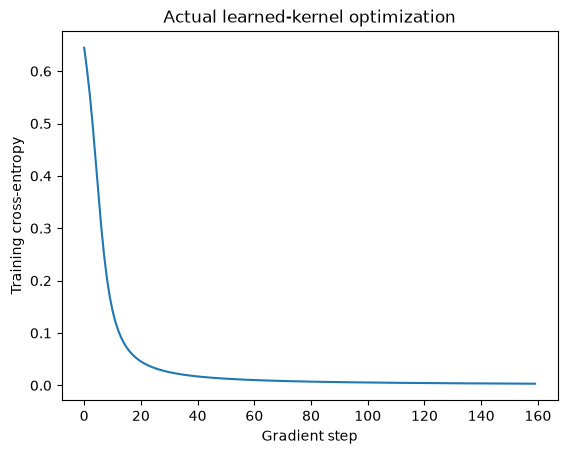

In [4]:
import matplotlib.pyplot as plt
plt.plot(history);plt.xlabel('Gradient step');plt.ylabel('Training cross-entropy')
plt.title('Actual learned-kernel optimization');plt.show()


## Deliberate failure and repair

Gradient ascent increases the loss because it moves in the derivative direction rather than its negative. Repair the update sign and keep the finite-difference check. If the training loss falls but held-out performance fails, inspect the data split and distribution rather than concluding that backpropagation is broken.

## Your investigation

Change bar position at test time without retraining and inspect the effect of the position-sensitive head. Count kernel and head parameters. Explain which gradients aggregate over shared spatial locations. Use AI to translate one NumPy layer into PyTorch and verify tensor shapes against the vendored tutorial before attempting its larger training assignment.

## Transfer to real neuroimaging

The original NMA notebook includes PyTorch and image-based exercises with additional resources. Our core is an actual CPU-trained convolutional classifier on invented bars. A 3D MRI network requires geometry-aware loading, channel contracts, participant splits, training infrastructure, and independent validation.

**Primary teaching sources, pinned where hosted on GitHub:**

- [NMA DL: CNNs (vendored)](https://github.com/NeuromatchAcademy/course-content-dl/blob/caba36c513fb8139ac3c9e7503f7a769dadde25e/tutorials/W2D2_Convnets/student/W2D2_Tutorial1.ipynb)
- [NMA DL: optimization](https://github.com/NeuromatchAcademy/course-content-dl/blob/caba36c513fb8139ac3c9e7503f7a769dadde25e/tutorials/W1D4_Optimization/student/W1D4_Tutorial1.ipynb)

Pinned upstream tutorials are a separate assignment; they have **not been executed** by this core lab. They may require data downloads, specialist dependencies, unfinished student cells, and additional compute.

## Exit questions and answer key

1. Which parameters actually learned? **Both convolution kernels, the head weights, and the head bias.**
2. What does the gradient check establish? **Agreement of one analytic derivative with a numerical slope, not clinical validity or correctness of every modeling choice.**

### Return to the research question

Reopen [PM03](../../curriculum/papers/modeling.md#pm03), [PM04](../../curriculum/papers/modeling.md#pm04) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
